In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/stock_details_5_years.csv')

df.head()
# print(df.head(3))
# print(df.tail(2))
# df.info()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


Data Set Exploration Continued... Additional Visual Analysis

Update Data Card with Previous Sprints 

In [3]:
dc = {}
dc["shape"] = df.shape
dc["cols"]  = df.columns.tolist()
dc["nulls"] = df.isna().sum().to_dict()

# parse Date for later steps; keep UTC like PA2
df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")

dc["date_min"] = df["Date"].min()
dc["date_max"] = df["Date"].max()
dc

{'shape': (602962, 9),
 'cols': ['Date',
  'Open',
  'High',
  'Low',
  'Close',
  'Volume',
  'Dividends',
  'Stock Splits',
  'Company'],
 'nulls': {'Date': 0,
  'Open': 0,
  'High': 0,
  'Low': 0,
  'Close': 0,
  'Volume': 0,
  'Dividends': 0,
  'Stock Splits': 0,
  'Company': 0},
 'date_min': Timestamp('2018-11-29 05:00:00+0000', tz='UTC'),
 'date_max': Timestamp('2023-11-29 05:00:00+0000', tz='UTC')}

Make Structure Easier to Read / See with these minimal transformations

In [4]:
df = df.sort_values('Date').copy()

top20 = df.groupby('Company')['Volume'].sum().nlargest(20).index
df_top = df[df['Company'].isin(top20)].copy()

# Create rolling mean of stocks to compare absolute mean
window = 30
df_top['Rolling_Close'] = (
    df_top.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window, min_periods=1).mean())
)

# Normalize Close prices to 100 at first date to compare growth
df_top['Indexed_Close'] = (
    df_top['Close'] /
    df_top.groupby('Company')['Close'].transform('first') * 100
)

strucutre the data to figures and graph for analysis

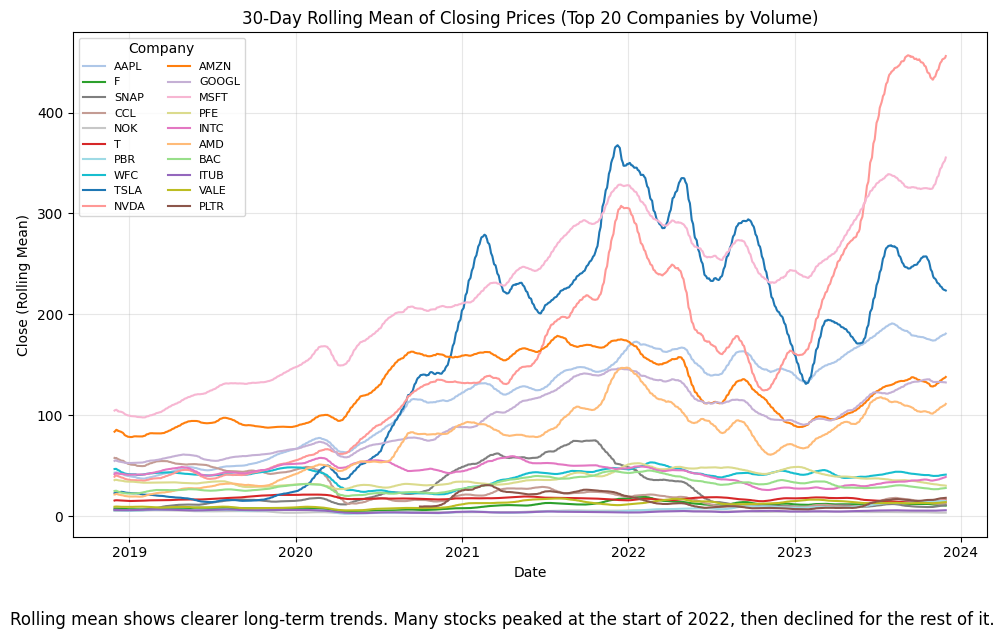

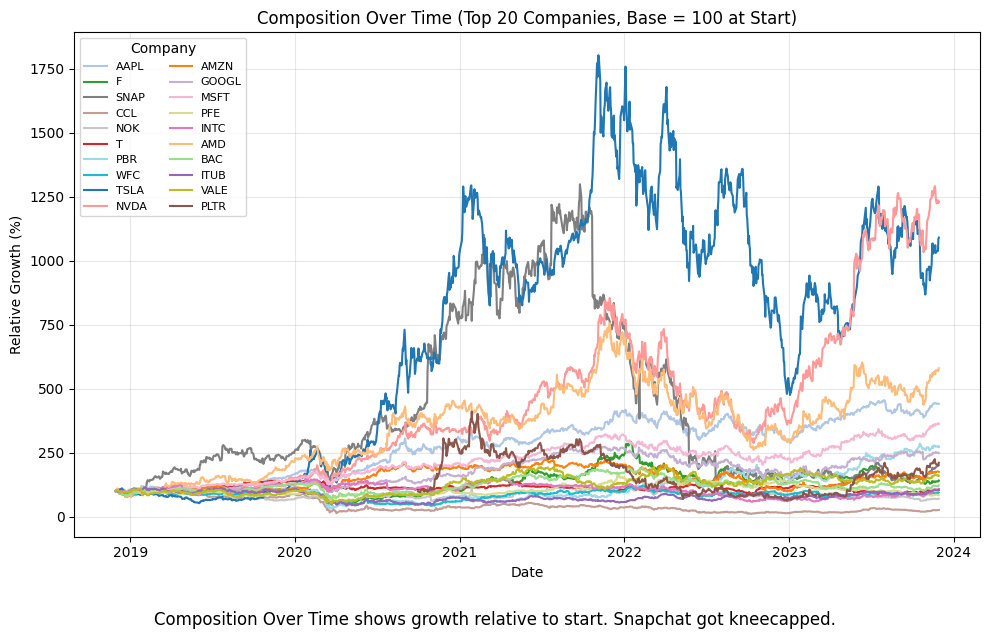

In [5]:
# Define colors
palette = sns.color_palette("tab20", len(top20))
color_map = dict(zip(top20, palette))

# Rolling Mean Plot
plt.figure(figsize = (10, 6))
sns.lineplot(
    data = df_top,
    x = 'Date',
    y = 'Rolling_Close',
    hue = 'Company',
    palette = color_map,
    linewidth = 1.5,
    legend = 'brief'
)
plt.title(f"{window}-Day Rolling Mean of Closing Prices (Top 20 Companies by Volume)")
plt.xlabel("Date")
plt.ylabel("Close (Rolling Mean)")
plt.legend(title = "Company", loc = "upper left", ncol = 2, fontsize = 8)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.figtext(
    0.5, -0.05,
    "Rolling mean shows clearer long-term trends. Many stocks peaked at the start of 2022, then declined for the rest of it.",
    wrap = True, ha = "center", fontsize = 12
)
plt.show()

# Composition Over Time Plot
plt.figure(figsize = (10, 6))
sns.lineplot(
    data = df_top,
    x = 'Date',
    y = 'Indexed_Close',
    hue = 'Company',
    palette = color_map,
    linewidth = 1.5,
    legend = 'brief'
)

plt.title("Composition Over Time (Top 20 Companies, Base = 100 at Start)")
plt.xlabel("Date")
plt.ylabel("Relative Growth (%)")
plt.legend(title = "Company", loc = "upper left", ncol = 2, fontsize = 8)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.figtext(
    0.5, -0.05,
    "Composition Over Time shows growth relative to start. Snapchat got kneecapped.",
    wrap = True, ha = "center", fontsize = 12
)
plt.show()


quantifcication / heatmap done for easier analysis

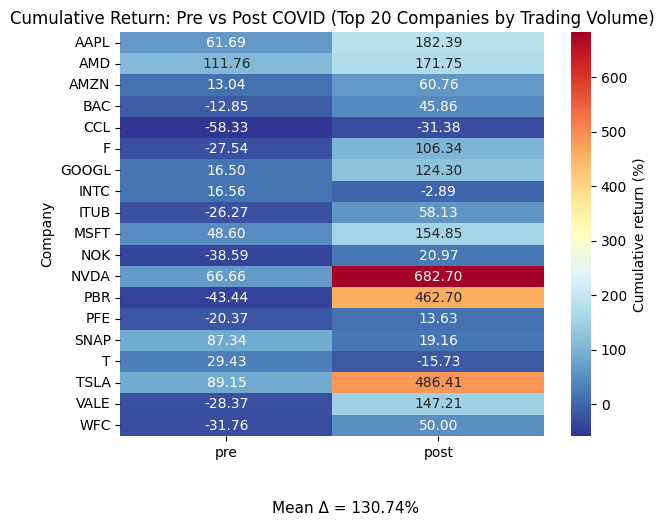

In [6]:
# Pre/post COVID cumulative return heatmap and mean delta
covid_date = pd.Timestamp("2020-03-11", tz="UTC")
df_use = df_top.copy()
df_use = df_use.sort_values(['Company', 'Date'])

def cumret(g):
    return g['Close'].iloc[-1] / g['Close'].iloc[0] - 1 if len(g) > 1 else np.nan

pre = df_use[df_use['Date'] < covid_date].groupby('Company').apply(cumret)
post = df_use[df_use['Date'] >= covid_date].groupby('Company').apply(cumret)
df_cr = pd.DataFrame({'pre': pre, 'post': post}).dropna()
df_cr['delta'] = (df_cr['post'] - df_cr['pre']) * 100
mean_delta = df_cr['delta'].mean()

sns.heatmap(df_cr[['pre', 'post']] * 100, annot=True, fmt=".2f", cmap="RdYlBu_r", cbar_kws={'label': 'Cumulative return (%)'})
plt.title("Cumulative Return: Pre vs Post COVID (Top 20 Companies by Trading Volume)")
plt.ylabel("Company")
plt.xlabel("")
plt.tight_layout()
plt.figtext(0.5, -0.08, f"Mean Δ = {mean_delta:.2f}%", ha='center', fontsize=11)
plt.show()